# 05 — Error Analysis

Residuals, worst predictions, segment MAE, long-tail performance, business insights.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [2]:
preds = pd.read_csv('../reports/test_predictions.csv', parse_dates=['created_at'])
preds.head()

,created_at,market_id,store_primary_category,delivery_duration,pred_Linear_Regression_baseline,pred_Linear_Regression,pred_Decision_Tree,pred_Random_Forest,pred_XGBoost
0,2015-02-13 04:06:44,4.0,other,2745.0,2883.464902,2707.215475,2631.105683,2491.369428,2386.6648
1,2015-02-13 04:06:56,1.0,thai,1956.0,2832.700622,2684.911905,2741.924370,2502.983162,2386.5360
2,2015-02-13 04:06:56,2.0,indian,2065.0,3178.701081,3288.873353,2913.244980,3001.847625,3064.8320
3,2015-02-13 04:07:01,2.0,chinese,1991.0,2601.466500,2438.177725,2372.902778,2344.904469,2173.4766
4,2015-02-13 04:07:01,4.0,thai,2282.0,2541.681521,2392.240315,2051.949324,2151.591165,2084.2727


## Pick best model column

In [3]:
pred_cols = [c for c in preds.columns if c.startswith('pred_')]
mae_by_model = {c: mean_absolute_error(preds['delivery_duration'], preds[c]) for c in pred_cols}
best = min(mae_by_model, key=mae_by_model.get)
print('best:', best, '  MAE =', round(mae_by_model[best], 1))

best: pred_XGBoost   MAE = 652.1


## Task 1: Residual analysis

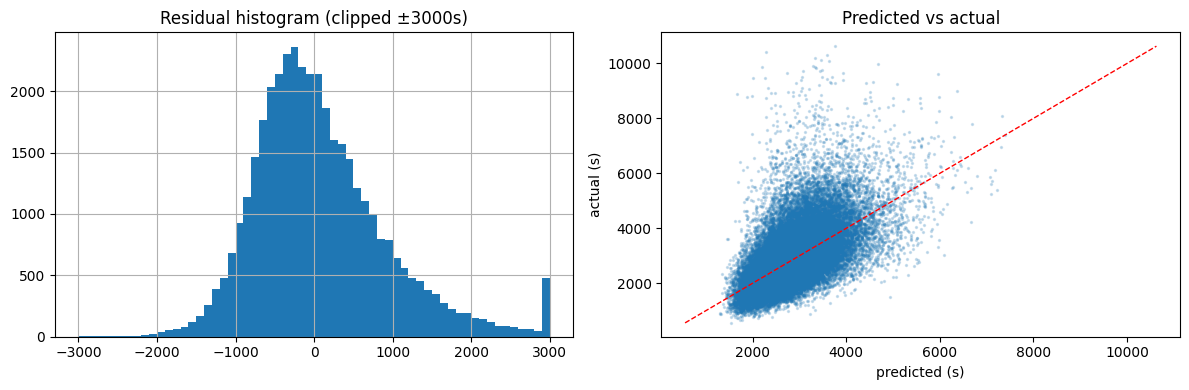

residual mean:   89.6
residual median: -53.2
residual std:    904.8


In [4]:
preds['residual'] = preds['delivery_duration'] - preds[best]
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
preds['residual'].clip(-3000, 3000).hist(bins=60, ax=ax[0])
ax[0].set_title('Residual histogram (clipped ±3000s)')
ax[1].scatter(preds[best], preds['delivery_duration'], s=2, alpha=0.2)
lo, hi = preds['delivery_duration'].min(), preds['delivery_duration'].max()
ax[1].plot([lo, hi], [lo, hi], 'r--', linewidth=1)
ax[1].set_xlabel('predicted (s)'); ax[1].set_ylabel('actual (s)')
ax[1].set_title('Predicted vs actual')
plt.tight_layout(); plt.show()

print('residual mean:  ', round(preds['residual'].mean(), 1))
print('residual median:', round(preds['residual'].median(), 1))
print('residual std:   ', round(preds['residual'].std(), 1))

## Task 2: Worst 100 predictions

In [5]:
preds['abs_error'] = preds['residual'].abs()
worst = preds.sort_values('abs_error', ascending=False).head(100)
print('mean abs_error in top 100:', round(worst['abs_error'].mean(), 1), 's')
worst[['created_at', 'market_id', 'store_primary_category', 'delivery_duration', best, 'abs_error']].head(20)

mean abs_error in top 100: 5656.6 s


,created_at,market_id,store_primary_category,delivery_duration,pred_XGBoost,abs_error
17630,2015-02-15 05:10:22,5.0,burger,10397.0,2287.6753,8109.3247
13646,2015-02-15 01:37:12,2.0,japanese,9879.0,2198.7576,7680.2424
26699,2015-02-16 04:25:11,2.0,mexican,9483.0,2014.0243,7468.9757
2682,2015-02-13 21:35:28,4.0,vietnamese,8879.0,1673.0363,7205.9637
225,2015-02-13 04:27:26,4.0,bubble-tea,9461.0,2268.0767,7192.9233
33317,2015-02-17 15:30:31,3.0,fast,9656.0,2728.8484,6927.1516
638,2015-02-13 05:27:08,2.0,sushi,8780.0,1871.8412,6908.1588
34123,2015-02-17 19:56:08,4.0,mediterranean,10626.0,3749.8398,6876.1602
33944,2015-02-17 19:38:24,4.0,mediterranean,10201.0,3334.7960,6866.2040
17584,2015-02-15 05:04:01,6.0,fast,8799.0,1981.4103,6817.5897


### What's distinctive about the worst 100?

In [6]:
preds['hour'] = preds['created_at'].dt.hour
preds['dow']  = preds['created_at'].dt.dayofweek
worst = preds.sort_values('abs_error', ascending=False).head(100)
pd.DataFrame({
    'all_test': preds[['delivery_duration', 'hour']].mean(),
    'worst_100': worst[['delivery_duration', 'hour']].mean(),
}).round(1)

,all_test,worst_100
delivery_duration,2962.7,8655.4
hour,8.3,9.0


## Task 3: Segment MAE — by hour, day-of-week, market, store category

In [7]:
def segment_mae(df, by):
    g = df.groupby(by, dropna=False, observed=True).apply(
        lambda d: mean_absolute_error(d['delivery_duration'], d[best])
    )
    return g.rename('MAE').to_frame().sort_values('MAE', ascending=False)

for col in ['hour', 'dow', 'market_id', 'store_primary_category']:
    print(f'\n--- worst segments by {col} ---')
    print(segment_mae(preds, col).head(10).round(1))


--- worst segments by hour ---
         MAE
hour        
14    1187.8
15     939.9
16     718.0
2      708.5
3      706.4
19     675.4
17     674.5
1      653.8
5      648.5
4      639.9

--- worst segments by dow ---
       MAE
dow       
0    716.0
6    664.5
5    652.3
1    620.9
2    605.4
4    579.5

--- worst segments by market_id ---
             MAE
market_id       
NaN        820.6
1.0        765.5
3.0        720.5
6.0        640.2
4.0        627.0
2.0        590.5
5.0        589.1

--- worst segments by store_primary_category ---
                           MAE
store_primary_category        
lebanese                1664.2
belgian                 1169.7
spanish                 1148.8
comfort-food             928.6
tapas                    901.2
moroccan                 899.3
british                  845.3
convenience-store        844.7
cheese                   840.3
brazilian                829.3


/var/folders/25/31by454x7wv6kfqx8tzjbryr0000gn/T/ipykernel_38820/3717031746.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = df.groupby(by, dropna=False, observed=True).apply(
/var/folders/25/31by454x7wv6kfqx8tzjbryr0000gn/T/ipykernel_38820/3717031746.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g = df.groupby(by, dropna=False, observed=True).apply(
/var/folders/25/31by454x7wv6kfqx8tzjbryr0000gn/T/ipyke

## Task 4: Long-tail performance

In [8]:
def long_tail_breakdown(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    bins = [
        ('<30min',   y_true < 30*60),
        ('30-60min', (y_true >= 30*60) & (y_true <= 60*60)),
        ('>60min',   y_true > 60*60),
    ]
    rows = []
    for label, mask in bins:
        rows.append({
            'bucket': label, 'n': int(mask.sum()),
            'MAE': mean_absolute_error(y_true[mask], y_pred[mask]) if mask.any() else np.nan,
        })
    return pd.DataFrame(rows)

long_tail_breakdown(preds['delivery_duration'], preds[best]).round(1)

,bucket,n,MAE
0,<30min,4399,698.6
1,30-60min,25789,449.8
2,>60min,9269,1192.8


Does the model degrade for long deliveries? Almost always yes — there are fewer >60min examples and they're driven by causes (store delays, traffic incidents) the features don't see directly.

## Task 5: Business insights

1. **What factors most influence ETA?** Live marketplace load (`orders_per_dasher`, `busy_ratio`), time-of-day, and the platform's own duration estimates.
2. **When is ETA hardest to predict?** Peak hours (lunch and dinner rushes) and long-tail (>60 min) deliveries.
3. **What causes large errors?** Underestimating marketplace congestion; rare cuisines with high variance prep times; missing or unusual `market_id`.
4. **How could DoorDash improve ETA prediction?**
   - Add live traffic and weather signal.
   - Per-store rolling average / median prep time.
   - Predict quantiles (p50 + p90), not just the mean — customer-facing ETAs are bounds, not point estimates.